## Import Libraries

In [46]:
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
mpl.style.use('ggplot')

In [71]:
import sklearn
sklearn.__version__

'1.8.0'

## Import Data

In [4]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"
df = pd.read_csv(URL)
df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


## Data Preparation

1. Impute missing values with the column mean
2. Drop duplicate rows from the data frame

In [5]:
# columns with missing values
missing_cols = df.columns[df.isna().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

Columns with missing values: ['tax']


In [6]:
# replace missing values 
df[missing_cols] = df[missing_cols].fillna(df[missing_cols].mean())

In [7]:
# delete duplicate row
df = df.drop_duplicates()

## Data Insights and Visualization

1. Get top 5 features most correlated to the target `price`.
2. Count the number of cars for each value of `fuelType`.
3. Create a box plot with Seaborn to find the `transmission` type with the most price outliers.
4. Create a regression plot between `mpg` and `price`.

In [8]:
target = "price"

# instantiate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# extract correlations to price
target_corr = corr_matrix[target].drop(labels=[target])

# get top 5 features with highest correlation
top5 = target_corr.abs().sort_values(ascending=False).head(5)
top5

year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
Name: price, dtype: float64

In [72]:
fuel_counts = df['fuelType'].value_counts(normalize=True)
fuel_counts

fuelType
Petrol      0.678251
Diesel      0.320346
Hybrid      0.001235
Electric    0.000112
Other       0.000056
Name: proportion, dtype: float64

Most Ford cars in this dataset rely on petrol.

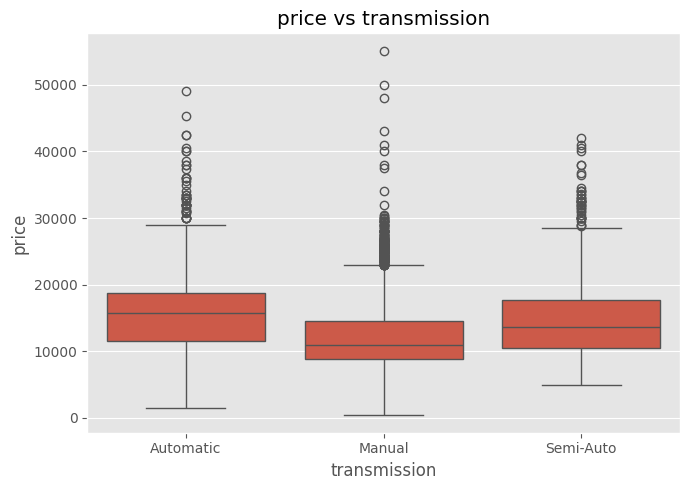

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='transmission',
    y='price'
)
plt.title(f'price vs transmission')
plt.tight_layout()
plt.show()

From the boxplot, it appears that the manual transmission has the largest number of price outliers.

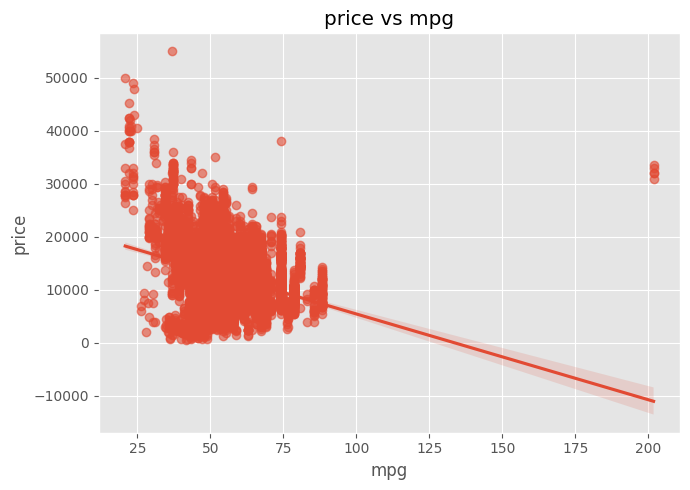

In [11]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x='mpg',
    y='price',
    scatter_kws={'alpha':0.6}
)
plt.title('price vs mpg')
plt.tight_layout()
plt.show()

Price appears to decrease as mpg rises.

## Model Development and Evaluation

1. Fit a linear regression model to predict `price` using `mpg`. Calculate the R^2 and MSE scores.
2. Fit a linear regression model to predict `price` using the 5 most correlated features:
    - `year`, `mileage`,`engineSize`, `tax`, and `mpg`
Calculate the R^2 and MSE scores.
3. Create a pipeline with the following arguments:
    - StandardScaler: standardize features
    - Second degree polynomial features
    - Linear regression model
Calculate the R^2 and MSE scores.
4. Perform the following operations:
    - Split the data into training and testing sets. 
    - Use a test size of 0.2. 
    - Create and fit a Ridge regression object using the training data. 
    - Set the regularization parameter to 0.1. 
    - Calculate R^2 and MSE scores for the test data.
5. Perform the following operations:
    - Use a second order polynomial transform on the training and testing sets. 
    - Create and fit a Ridge regression object with the modified training data. 
    - Set the regularization parameter to 0.1. 
    - Calculate the R^2 and MSE scores for the modified test data.
6. Perform the following operations:
    - apply Grid Search on a Ridge Regression model for alpha (0.01, 0.1, 1, 10, 100)
    - Use 4-fold cross validation
    - Find best alpha value

In [25]:
# function to compute R^2 and MSE scores 
def get_score(y, y_pred):
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    print(f"R^2 score: {r2:.4f}")
    print(f"MSE score: {mse:.0f}")

In [13]:
# get feature and target
X = df[['mpg']]
y = df['price']

# instantiate and fit a Linear Regression model object
model = LinearRegression().fit(X, y)

# make a prediction
y_pred = model.predict(X)

# compute the R^2 and MSE scores
get_score(y, y_pred)

R^2 score: 0.1199
MSE score: 19741691


This model performs poorly as `mpg` alone only explains about 12% of the variance in `price`.

In [14]:
# get top 5 features correlated to price as a list
top5_features = top5.index.tolist()

In [87]:
# get top 5 features and target
X = df[top5_features]
y = df['price']

# instantiate and fit a Linear Regression model object
model = LinearRegression().fit(X, y)

# make a prediction
y_pred = model.predict(X)

# compute the R^2 and MSE scores
get_score(y, y_pred)

# examine the predicted prices
print(min(y_pred), max(y_pred))

R^2 score: 0.7265
MSE score: 6134065
-10892.512996838894 64448.18512450671


<Axes: >

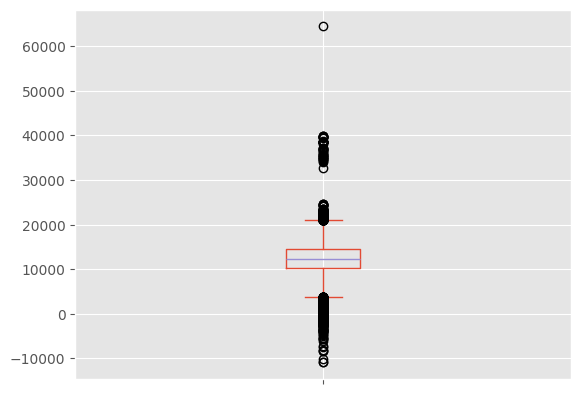

In [16]:
y_pred_s = pd.Series(y_pred)
y_pred_s.plot(
    kind='box'
)

The model achieves a much better R^2 score, explaining about 73% of the variance. However, this model is still unreliable as there are negative price predictions.

In [83]:
# get top 5 features and target
X = df[top5_features]
y = df['price']

# instantiate the pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

# fit the pipeline
pipeline.fit(X, y)

# make a prediction
y_pred = pipeline.predict(X)

# compute the R^2 and MSE scores
get_score(y, y_pred)

R^2 score: 0.7667
MSE score: 5234038


The pipeline achieves a slightly improved R^2 score, explaining about 77% of the variance.

In [94]:
# get top 5 features and target
X = df[top5_features]
y = df['price']

# create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# create and fit a Ridge regression model
model = Ridge(alpha=0.1).fit(X_train, y_train)

# make a prediction on the test set
y_pred = model.predict(X_test)

# compute the R^2 and MSE scores
get_score(y_test, y_pred)

R^2 score: 0.6917
MSE score: 6912726


In [95]:
# get top 5 features and target
X = df[top5_features]
y = df['price']

# create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# apply second order polynomial transform and training and test features
poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()

X_train_poly = poly.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_poly)

X_test_poly = poly.transform(X_test)
X_test_scaled = scaler.transform(X_test_poly)

# create and fit a Ridge regression model
model = Ridge(alpha=0.1).fit(X_train_scaled, y_train)

# make a prediction on the scaled test set
y_pred = model.predict(X_test_scaled)

# compute the R^2 and MSE scores
get_score(y_test, y_pred)

R^2 score: 0.6914
MSE score: 6919636


In [96]:
# get top 5 features and target
X = df[top5_features]
y = df["price"]

# create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# create pipeline for feature transformation
pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

# parameter grid for Ridge model
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

# GridSearch object
ridge_cf = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

# Fit the grid
ridge_cf.fit(X_train, y_train)

# make a prediction on the scaled test set
y_pred = model.predict(X_test_scaled)

# compute the R^2 and MSE scores
get_score(y_test, y_pred)

# find best alpha
print(f'Best alpha: {ridge_cf.best_params_["ridge__alpha"]}')

R^2 score: 0.6914
MSE score: 6919636
Best alpha: 0.01
